# 🔬 Continuous Hybrid Tracker
This notebook combines our high-resolution `numpy` FFT Transient Extractor with the powerful Localized Continuous Phase Sweep.

Here, `Listener` acts simply to **initialize a search radius**. We sweep a continuous phase float array at high resolution (0.1 BPM) in a tiny local region around what the classic Flywheel suspects the BPM is. This gives sub-BPM float precision. We then throw those projected phase beats into our Magnetic 5-Second Lookahead Buffer to snap onto the exact physical transients.


In [1]:
import librosa
import numpy as np
import torchaudio
import torch
import time
from collections import deque
import warnings
warnings.filterwarnings('ignore')

import sys
import os
sys.path.append(os.path.abspath('..'))

# Import core infrastructure
import core.Listener as ListenerModule
from IPython.display import display, clear_output

def default_infos():
    return {
        "startServer"     : False ,
        "useMicrophone"   : True  ,
        "HARDWARE_MODE"   : "simulation",
        "onRaspberry"     : False  ,

        "printTimeOfCalculation" : False ,
        "printModesDetails"      : True ,
        "printMicrophoneDetails" : False ,
        "printAppDetails"        : False ,
        "printAsservmentDetails" : False ,
        "printConfigurationLoads": False ,
        "printConfigChanges"     : False ,

        "modesToPrintDetails"    : ["PSG"]
    }




### 1. The Ground Truth Evaluation Benchmark


In [2]:
root = '../assets/musics/mp3_files/'
song_files = [
    'Palladium.mp3',
    #'Pumped Up Kicks.mp3',
    'Nobody Rules the Streets.mp3',
    #'Sugar (feat. Francesco Yates).mp3'
]

for song_id in range(len(song_files)):
    song_files[song_id] = root + song_files[song_id]


print(f"Loading {len(song_files)} songs sequentially for Song Change Test...")

y_list = []
onset_list = []
true_beat_times_list = []
current_shift_time = 0.0
tempo_librosa = 120.0 # Default fallback

import os
librosa_dir = os.path.join(root, 'librosa')
os.makedirs(librosa_dir, exist_ok=True)

for i, f in enumerate(song_files):
    basename = os.path.basename(f)
    save_path = os.path.join(librosa_dir, f"{basename}.npz")
    
    if os.path.exists(save_path):
        print(f"Loading pre-computed Librosa analysis for Song {i+1}...")
        data = np.load(save_path, allow_pickle=True)
        y = data['y']
        sr = int(data['sr'])
        onset = data['onset']
        t = data['t']
        bf = data['bf']
    else:
        print(f"Running non-causal Librosa Beat Track on Song {i+1}...")
        y, sr = librosa.load(f, sr=44100)
        print(1)
        onset = librosa.onset.onset_strength(y=y, sr=sr)
        print(2)
        t, bf = librosa.beat.beat_track(onset_envelope=onset, sr=sr)
        print(3)
        np.savez(save_path, y=y, sr=sr, onset=onset, t=t, bf=bf)
        
    y_list.append(y)
    onset_list.append(onset)
    
    if i == 0:
        tempo_librosa = float(t[0]) if hasattr(t, '__len__') else float(t) # Used for first plot line
    
    bt = librosa.frames_to_time(bf, sr=sr)
    true_beat_times_list.append(bt + current_shift_time)
    
    current_shift_time += len(y) / float(sr)


Loading 2 songs sequentially for Song Change Test...
Loading pre-computed Librosa analysis for Song 1...
Loading pre-computed Librosa analysis for Song 2...


### 2. High Resolution FFT Microphones


In [3]:
class Robust_Simulated_Microphone:
    def __init__(self, y_full_array, bandValues, infos):
        self.bandValues = bandValues
        self.nb_of_fft_band = len(self.bandValues)
        
        self.sample_rate = 44100
        self.buffer_size = 1024 
        self.audio_data = np.zeros(self.buffer_size)
        
        # Ensure array is float and flattened appropriately to avoid truncation
        self.full_audio = y_full_array
        self.total_samples = len(self.full_audio)
        self.current_pos = 0
        
        fft_size = self.buffer_size // 2 + 1
        self.weight_matrix = np.zeros((self.nb_of_fft_band, fft_size))
        
        def hz_to_mel(f): return 2595 * np.log10(1 + f / 700.0)
        def mel_to_hz(m): return 700 * (10**(m / 2595.0) - 1)
        
        lower_mel = hz_to_mel(20)
        upper_mel = hz_to_mel(20000)
        mel_points = np.linspace(lower_mel, upper_mel, self.nb_of_fft_band + 2)
        hz_points = mel_to_hz(mel_points)
        bin_points = np.floor((self.buffer_size + 1) * hz_points / self.sample_rate).astype(int)
        
        for i in range(self.nb_of_fft_band):
            start = min(bin_points[i], fft_size - 1)
            mid = min(bin_points[i + 1], fft_size - 1)
            end = min(bin_points[i + 2], fft_size - 1)
            if mid > start:
                self.weight_matrix[i, start:mid] = np.linspace(0, 1, mid - start, endpoint=False)
            if end > mid:
                self.weight_matrix[i, mid:end] = np.linspace(1, 0, end - mid, endpoint=False)
            band_sum = np.sum(self.weight_matrix[i, :])
            if band_sum > 0:
                self.weight_matrix[i, :] /= band_sum
                
        self.raw_fft_history = None
        self.bass_flux = 0.0
        self.treble_flux = 0.0
        self.high_res_flux = 0.0

    def pop_chunk(self, chunk_size=1024):
        if self.current_pos + chunk_size > self.total_samples:
            return False 
        
        incoming = self.full_audio[self.current_pos : self.current_pos + chunk_size]
        self.current_pos += chunk_size
        self.audio_data = np.roll(self.audio_data, -chunk_size)
        self.audio_data[-chunk_size:] = incoming
        return True

    def calculate_fft(self):
        windowed_data = self.audio_data * np.hanning(self.buffer_size)
        fft_result = np.abs(np.fft.rfft(windowed_data))
        
        scale = 150.0 / (self.buffer_size / 1024.0)
        mel_bands = np.dot(self.weight_matrix, fft_result) * scale
        for i in range(self.nb_of_fft_band):
            self.bandValues[i] = int(mel_bands[i])

        if self.raw_fft_history is not None:
            freq_diff = np.maximum(0, fft_result - self.raw_fft_history)
            self.bass_flux = np.sum(freq_diff[1:7])
            self.treble_flux = np.sum(freq_diff[70:300])
            self.high_res_flux = self.treble_flux
        self.raw_fft_history = fft_result



### 3. Localized Continuous Phase Sweep & Float Flywheel
This cuts computation by ~95% by only exploring around a center BPM given by the Listener.py guide.


In [4]:
def localized_continuous_phase_sweep(odf_buffer, center_bpm, search_radius=1.5, step=0.3, expected_phase=None):
    odf_size = len(odf_buffer)
    decay_curve = np.exp(-1.5 * np.linspace(1.0, 0.0, odf_size))
    weighted_buffer = odf_buffer * decay_curve
    
    best_overall_score = -float('inf')
    best_overall_bpm = center_bpm
    best_overall_p = 0
    
    buffer_indices = np.arange(odf_size)
    
    # Tiny localized search area explicitly restricted to ± radius around the Flywheel's best guess
    bpm_evals = np.arange(max(50.0, center_bpm - search_radius), min(220.0, center_bpm + search_radius + step/2), step)
    
    btrack_fps = 60.0
    const_part = buffer_indices - (odf_size - 1)
    
    for bpm_val in bpm_evals:
        tau_val = 60.0 * btrack_fps / bpm_val
        p_max = int(np.ceil(tau_val))
        
        p_arr = np.arange(p_max)[:, None]
        phase_float = (const_part[None, :] + p_arr) % tau_val
        norm_phi = phase_float / tau_val 
        
        abs_phi = np.abs(norm_phi - 0.5)
        mask_high = abs_phi >= 0.475
        mask_medium = abs_phi <= 0.025
        template_vals = np.full((p_max, odf_size), -0.2)
        template_vals[mask_high] = 0.9 + 0.6 * (0.025 - (0.5 - abs_phi[mask_high]))
        template_vals[abs_phi <= 0.025] = 0.6+ 0.3 * (0.025-(abs_phi[mask_medium]))
        template_vals[((abs_phi >= 0.22) & (abs_phi <= 0.28))] = 0.0 # Sub-sub-beats get neutral weight (0.0)
        
        p_scores = np.sum(weighted_buffer[None, :] * template_vals, axis=1)
        
        # --- NEW: PHASE INERTIA LOGIC ---
        # If we have an established tracker momentum, gently penalize severe phase jumps 
        # (reduces the likelihood of 180-degree phase inversions caused by loud off-beats)
        if expected_phase is not None:
            expected_p = (expected_phase * tau_val) % tau_val
            
            # Shortest circular distance from candidate p to expected_p
            dist_p = np.minimum(np.abs(p_arr[:, 0] - expected_p), tau_val - np.abs(p_arr[:, 0] - expected_p))
            norm_dist = dist_p / tau_val
            
            # Gaussian phase momentum (punishes 0.5 offsets to prevent sub-beat locks)
            phase_inertia = np.exp(-0.5 * (norm_dist / 0.35)**2)
            
            # Blend the score so sudden off-beats lose their competitive symmetry
            p_scores = p_scores * (0.5 + 0.5 * phase_inertia)
        # --------------------------------
            
        tau_max_score = np.max(p_scores)
        best_p = np.argmax(p_scores)
        
        gaussian_weight = np.exp(-0.5 * ((bpm_val - center_bpm) / (search_radius * 1.5))**2)
        weighted_score = tau_max_score * (0.8 + 0.2 * gaussian_weight)
        
        if weighted_score > best_overall_score:
            best_overall_score = weighted_score
            best_overall_bpm = bpm_val
            best_overall_p = best_p
            
    # The normalized phase (0 to 1) of the MOST RECENT frame in the buffer is derived directly from p
    optimal_tau = 60.0 * btrack_fps / best_overall_bpm
    precise_phase = best_overall_p / optimal_tau
            
    return best_overall_bpm, precise_phase, best_overall_score


### 4. The 5-Second Magnetic Snap Execution Engine


In [ ]:
infos = default_infos()
infos["printAsservmentDetails"] = False 
infos["useMicrophone"] = True

SIMULATED_FPS = 60.0
TIME_PER_FRAME = 1.0 / SIMULATED_FPS
CHUNK_SIZE_FOR_60FPS = int(44100 / SIMULATED_FPS)

class MockTime:
    def __init__(self):
        self.current_time = 0.0
    def time(self):
        return self.current_time

mock_timer = MockTime()
ListenerModule.time.time = mock_timer.time

listener = ListenerModule.Listener(infos)
listener.ingestion.momentum_multiplier = 0.01
listener.dynamic_audio_latency = 0

y_full = np.concatenate(y_list)
mic = Robust_Simulated_Microphone(y_full, listener.ingestion.fft_band_values, infos)
listener.hasBeenSilenceCalibrated = True
listener.hasBeenBBCalibrated = True
listener.ingestion.calibrate_silence = lambda fps_ratio: None
listener.ingestion.calibrate_bb = lambda fps_ratio: None

lookahead_frames = int(8.5 * SIMULATED_FPS)
future_queue = deque()

algorithmic_beats = []
algorithmic_sub_beats = []
history_time = []
history_bpm = []
history_bass = []

history_treble = []
history_trust = []
history_stm_power = []
history_ltm_power = []
history_timbral_nov = []
history_power_nov = []
history_combined_nov = []
history_novelty_lm = []
history_novelty_gm = []
history_asserved_nov = []

history_standalone_phase = []
history_target_phase = []
history_bpm_divergence = []
history_snap_offset = []
history_ltm_bpm = []
track_target_phase = 0.0
track_bpm_divergence = 0.0

standalone_phase = 0.0
standalone_beat_count = 0
last_standalone_beat_count = 0
last_standalone_phase = 0.0
standalone_sub_beat_locked = -1

audio_time = 0.0
playhead_time = 0.0
frame = 0

frames_since_sweep = 0
frames_between_sweep = int(5 * SIMULATED_FPS)  # Sweep every 12 frames (5 Hz)


# Structural Novelty Variables
stm_timbre = np.zeros(8)
ltm_timbre = np.zeros(8)
stm_power = 0.0
ltm_power = 0.0
stm_weight = 0.02  # ~1.5s smoothing
ltm_weight = 0.0015 # ~6.0s smoothing

structural_changes = []
last_structural_change_frame = -9999
STRUCTURAL_COOLDOWN_FRAMES = int(20.0 * SIMULATED_FPS)

# Advanced Adaptive Cooldown
novelty_lm = 0.2
novelty_gm = 0.3
asserved_novelty = 0.0
NOVELTY_DECAY_RATE = 0.9999 # Reduce threshold by 0.1% every frame

power_weight = 0.2
SONG_NOVELTY_ASSERVED_TH = 0.75
STRUCTURAL_NOVELTY_ASSERVED_TH = 0.6 # Sensitivity to be tweaked later


song_changes = []
silence_frames = 0
SILENCE_THRESHOLD_FRAMES = int(1.5 * SIMULATED_FPS)

# BPM Trust Variables for Song Changes

long_term_bpm = 120.0
ltm_trust = 10.0 # Arbitrary warm-up scalar
bpm_jump_threshold = 8.0 # BPM change needed to trigger song reset
bpm_trust = 10.0 # Default starting trust

print("🚀 Starting Hybrid Simulation Loop...")

while mic.pop_chunk(CHUNK_SIZE_FOR_60FPS):
    mic.calculate_fft()
    listener.update()
    
    # 0. Feature Extraction & Novelty Detection (Verse/Chorus & Song boundaries)
    current_timbre = listener.band_proportion

    # Update Short-Term and Long-Term Memory
    stm_timbre = (1 - stm_weight) * stm_timbre + stm_weight * current_timbre
    ltm_timbre = (1 - ltm_weight) * ltm_timbre + ltm_weight * current_timbre
    
    current_power = listener.smoothed_total_power
    stm_power = (1 - stm_weight) * stm_power + stm_weight * current_power
    ltm_power = (1 - ltm_weight) * ltm_power + ltm_weight * current_power
    
    # Calculate Timbral Novelty (Euclidean distance)
    timbral_novelty = np.linalg.norm(stm_timbre - ltm_timbre)
    
    # Calculate Power Novelty (normalized by LTM to detect relative drops/surges)
    power_novelty = np.abs(stm_power - ltm_power) / (ltm_power + 1.0)
    
    # Combined Novelty Score
    combined_novelty = timbral_novelty + (power_novelty * 0.2)

    if combined_novelty>0.4 :
        combined_novelty = 0.4
    
    # === Local & Global Max Envelope (Asserved Normalization) ===
    if combined_novelty >= novelty_lm:
        novelty_lm = combined_novelty
    else:
        novelty_lm = max(0.15, novelty_lm * NOVELTY_DECAY_RATE)
        
    passed_gm = combined_novelty > novelty_gm
    if combined_novelty >= novelty_gm:
        novelty_gm = 1.01 * combined_novelty
    else:
        # Scale GM based on how close LM is to GM.
        novelty_gm *= 1 + 0.005 * ((novelty_lm / novelty_gm) - 0.7)
        
    safe_gm = max(0.01, novelty_gm)
    
    # Smooth the target normalization
    target_asserved = combined_novelty / safe_gm
    asserved_novelty += 0.4 * (target_asserved - asserved_novelty)
    
    # === Structural Detection against Normalized Threshold ===
    if asserved_novelty > SONG_NOVELTY_ASSERVED_TH:
        if len(song_changes) == 0 or (playhead_time - song_changes[-1]) > 20.0:
            song_changes.append(playhead_time)
            # We no longer clear the future_queue here
            standalone_beat_count = 0
            last_standalone_beat_count = 0
            standalone_sub_beat_locked = -1
            standalone_phase = 0.0
            listener.ingestion.band_means.fill(0.0)
            listener.ingestion.smoothed_fft_band_values.fill(0.0)
            listener.analyzer.odf_buffer.fill(0.0)
            
            # Reset System Envelopes to enforce an organic cooldown
            novelty_gm = combined_novelty * 1.5 
            asserved_novelty = 0.0
            ltm_timbre = np.copy(stm_timbre)
            ltm_power = stm_power
            
    elif passed_gm:
        # Classic Verse/Chorus change. We still enforce a flat base cooldown to prevent stuttering logic
        if (frame - last_structural_change_frame) > STRUCTURAL_COOLDOWN_FRAMES:
            structural_changes.append(playhead_time)
            last_structural_change_frame = frame
            
            
            asserved_novelty = 0.0
            ltm_timbre = np.copy(stm_timbre)
            ltm_power = stm_power

    # Song Change Detection (Silence / Trust Drop)
    if listener.smoothed_total_power < 5.0:
        silence_frames += 1
    else:
        silence_frames = 0
        
    if silence_frames > SILENCE_THRESHOLD_FRAMES:
        if len(song_changes) == 0 or (playhead_time - song_changes[-1]) > 5.0:
            song_changes.append(playhead_time)
            # We no longer clear the future_queue here
            standalone_beat_count = 0
            last_standalone_beat_count = 0
            standalone_sub_beat_locked = -1
            standalone_phase = 0.0
            
            # Reset Listener history
            listener.ingestion.band_means.fill(0.0)
            listener.ingestion.smoothed_fft_band_values.fill(0.0)
            listener.analyzer.odf_buffer.fill(0.0)

    
    # 1. Periodically run the Localized Continuous Precision Sweep centered around listener.bpm
    if frames_since_sweep >= frames_between_sweep:
        # Base Flywheel BPM serves strictly as a guide to restrict search space
        coarse_bpm = listener.bpm if (50 < listener.bpm < 220) else 120.0
        
        # --- NEW: Calculate the phase we EXPECT the ODF to present as the "most recent frame"
        total_latency = listener.dynamic_audio_latency + listener.analyzer.hardware_latency
        latency_phase_shift = (coarse_bpm / 60.0) * total_latency
        expected_p_phase = (standalone_phase - latency_phase_shift + 1.0) % 1.0
        
        # Only inject phase inertia if we have already confidently tracked at least a few beats
        inertia_param = expected_p_phase if standalone_beat_count > 5 else None
        
        precise_bpm, precise_phase, bpm_trust = localized_continuous_phase_sweep(
            listener.analyzer.odf_buffer, 
            center_bpm=coarse_bpm, 
            search_radius=1.5, 
            step=0.5,
            expected_phase=inertia_param
        )
        
        listener.analyzer.bpm = precise_bpm
        
        # --- BPM Trust Song Change Logic ---
        # 1. Update Long-Term smoothing
        if playhead_time < 5.0:
            long_term_bpm = precise_bpm
            ltm_trust = listener.analyzer.binary_trust
        else:
            long_term_bpm = 0.8 * long_term_bpm + 0.2 * precise_bpm
            ltm_trust = 0.9 * ltm_trust + 0.1 * listener.analyzer.binary_trust
        
        # 2. Detect Wild Departure 
        bpm_divergence = np.abs(precise_bpm - long_term_bpm)
        
        if bpm_divergence > bpm_jump_threshold and listener.analyzer.binary_trust < (ltm_trust * 0.6):
            if len(song_changes) == 0 or (playhead_time - song_changes[-1]) > 5.0:
                song_changes.append(playhead_time)
                # We no longer clear the future_queue here
                standalone_beat_count = 0
                last_standalone_beat_count = 0
                standalone_sub_beat_locked = -1
                standalone_phase = 0.0
                listener.ingestion.band_means.fill(0.0)
                listener.ingestion.smoothed_fft_band_values.fill(0.0)
                listener.analyzer.odf_buffer.fill(0.0)
                
                # Instantly accept the new tempo reality
                long_term_bpm = precise_bpm
        # -----------------------------------

        
        # EXTRACT TARGET SETTINGS: 
        # Calculate Listener's latency-shifted target phase (from float precision)
        latency_phase_shift_precise = (precise_bpm / 60.0) * total_latency
        target_phase = (precise_phase + latency_phase_shift_precise) % 1.0
        
        track_target_phase = target_phase
        track_bpm_divergence = bpm_divergence
        
        # Softly align the standalone phase towards the target phase 
        # (This completely eliminates the phase tug-of-war with Listener's internal loop)
        phase_diff = (target_phase - standalone_phase + 0.5) % 1.0 - 0.5
        
        # HARD RESET onto the precise sweep, but ONLY if we maintain temporal sanity
        if abs(phase_diff) < 0.15:
            standalone_phase += phase_diff * 1.0  
        else:
            # We reject the sweep as it likely aligned onto an off-beat / subdivision
            pass
        
        frames_since_sweep = 0
        
    frames_since_sweep += 1
    
    # 2. Advance the standalone phase steadily at precisely the tracked BPM
    phase_delta = (listener.bpm / 60.0) / SIMULATED_FPS
    standalone_phase += phase_delta
    
    while standalone_phase >= 1.0:
        standalone_phase -= 1.0
        standalone_beat_count += 1
    while standalone_phase < 0.0:
        standalone_phase += 1.0
        standalone_beat_count -= 1
    
    # 3. Check for standalone beat triggers without internal Listener conflicts
    is_beat = False
    is_sub_beat = False
    
    if standalone_beat_count > last_standalone_beat_count:
        is_beat = True
        last_standalone_beat_count = standalone_beat_count
        
    if last_standalone_phase < 0.5 and standalone_phase >= 0.5:
        # ANTI-BOUNCE SAFEGUARD: Force max 1 sub-beat per beatcycle threshold
        if standalone_sub_beat_locked < last_standalone_beat_count:
            is_sub_beat = True
            standalone_sub_beat_locked = last_standalone_beat_count
            
    last_standalone_phase = standalone_phase
    
    # 4. Queue up expectations using standalone phase log

    future_queue.append({
        'time': audio_time,
        'bpm': listener.bpm,
        'bass_flux': mic.bass_flux,
        'treble_flux': mic.treble_flux,
        'is_beat': is_beat,
        'is_sub_beat': is_sub_beat,
        'standalone_phase': standalone_phase,
        'target_phase': track_target_phase,
        'bpm_divergence': track_bpm_divergence,
        'long_term_bpm': long_term_bpm,
        'snap_offset': 0
    })
    
    # 4. RIGID BEAT POPPING
    # Pop beats precisely when they are 5 seconds old (rigidly locked to the continuous phase grid)
    while len(future_queue) > 0:
        time_diff = audio_time - future_queue[0]['time']
        
        if time_diff < 5.0:
            break
            
        present = future_queue.popleft()
        
        if present.get('is_beat', False):
            algorithmic_beats.append(playhead_time)
            
        if present.get('is_sub_beat', False):
            algorithmic_sub_beats.append(playhead_time)
            
        history_time.append(playhead_time)
        history_bpm.append(present['bpm'])
        history_bass.append(present.get('bass_flux', 0.0))
        history_treble.append(present.get('treble_flux', 0.0))
        history_trust.append(ltm_trust)
        history_stm_power.append(stm_power)
        history_ltm_power.append(ltm_power)
        history_timbral_nov.append(timbral_novelty)
        history_power_nov.append(power_novelty)
        history_combined_nov.append(combined_novelty)
        history_novelty_lm.append(novelty_lm)
        history_novelty_gm.append(novelty_gm)
        history_asserved_nov.append(asserved_novelty)
        history_standalone_phase.append(present.get('standalone_phase', 0.0))
        history_target_phase.append(present.get('target_phase', 0.0))
        history_bpm_divergence.append(present.get('bpm_divergence', 0.0))
        history_ltm_bpm.append(present.get('long_term_bpm', 120.0))
        history_snap_offset.append(present.get('snap_offset', 0))
        playhead_time += TIME_PER_FRAME
        
    audio_time += TIME_PER_FRAME
    mock_timer.current_time += TIME_PER_FRAME
    frame += 1
    
    if frame % 1800 == 0:
        print(f"Processed audio time {audio_time:.1f}s...")

ListenerModule.time.time = time.time 

# Final flush
while future_queue:
    present = future_queue.popleft()
    if present.get('is_beat', False):
        algorithmic_beats.append(playhead_time)
    if present.get('is_sub_beat', False):
        algorithmic_sub_beats.append(playhead_time)
    history_time.append(playhead_time)
    history_bpm.append(present['bpm'])
    history_bass.append(present.get('bass_flux', 0.0))
    history_treble.append(present.get('treble_flux', 0.0))
    history_trust.append(ltm_trust)
    history_stm_power.append(stm_power)
    history_ltm_power.append(ltm_power)
    history_timbral_nov.append(timbral_novelty)
    history_power_nov.append(power_novelty)
    history_combined_nov.append(combined_novelty)
    history_standalone_phase.append(present.get('standalone_phase', 0.0))
    history_target_phase.append(present.get('target_phase', 0.0))
    history_bpm_divergence.append(present.get('bpm_divergence', 0.0))
    history_ltm_bpm.append(present.get('long_term_bpm', 120.0))
    history_snap_offset.append(present.get('snap_offset', 0))
    playhead_time += TIME_PER_FRAME

alg_beats_array = np.array(algorithmic_beats)
alg_sub_beats_array = np.array(algorithmic_sub_beats)
print(f"✅ Simulation Loop Complete! Extracted {len(alg_beats_array)} Hybrid Beats and {len(alg_sub_beats_array)} Hybrid Sub-beats.")



🚀 Starting Hybrid Simulation Loop...
Processed audio time 30.0s...
Processed audio time 60.0s...
Processed audio time 90.0s...
Processed audio time 120.0s...
Processed audio time 150.0s...
Processed audio time 180.0s...
Processed audio time 210.0s...
Processed audio time 240.0s...
Processed audio time 270.0s...
Processed audio time 300.0s...
Processed audio time 330.0s...
Processed audio time 360.0s...
Processed audio time 390.0s...
Processed audio time 420.0s...
Processed audio time 450.0s...
Processed audio time 480.0s...
Processed audio time 510.0s...
Processed audio time 540.0s...
Processed audio time 570.0s...
Processed audio time 600.0s...
Processed audio time 630.0s...
✅ Simulation Loop Complete! Extracted 1033 Hybrid Beats and 1040 Hybrid Sub-beats.


### 6. BPM Performances

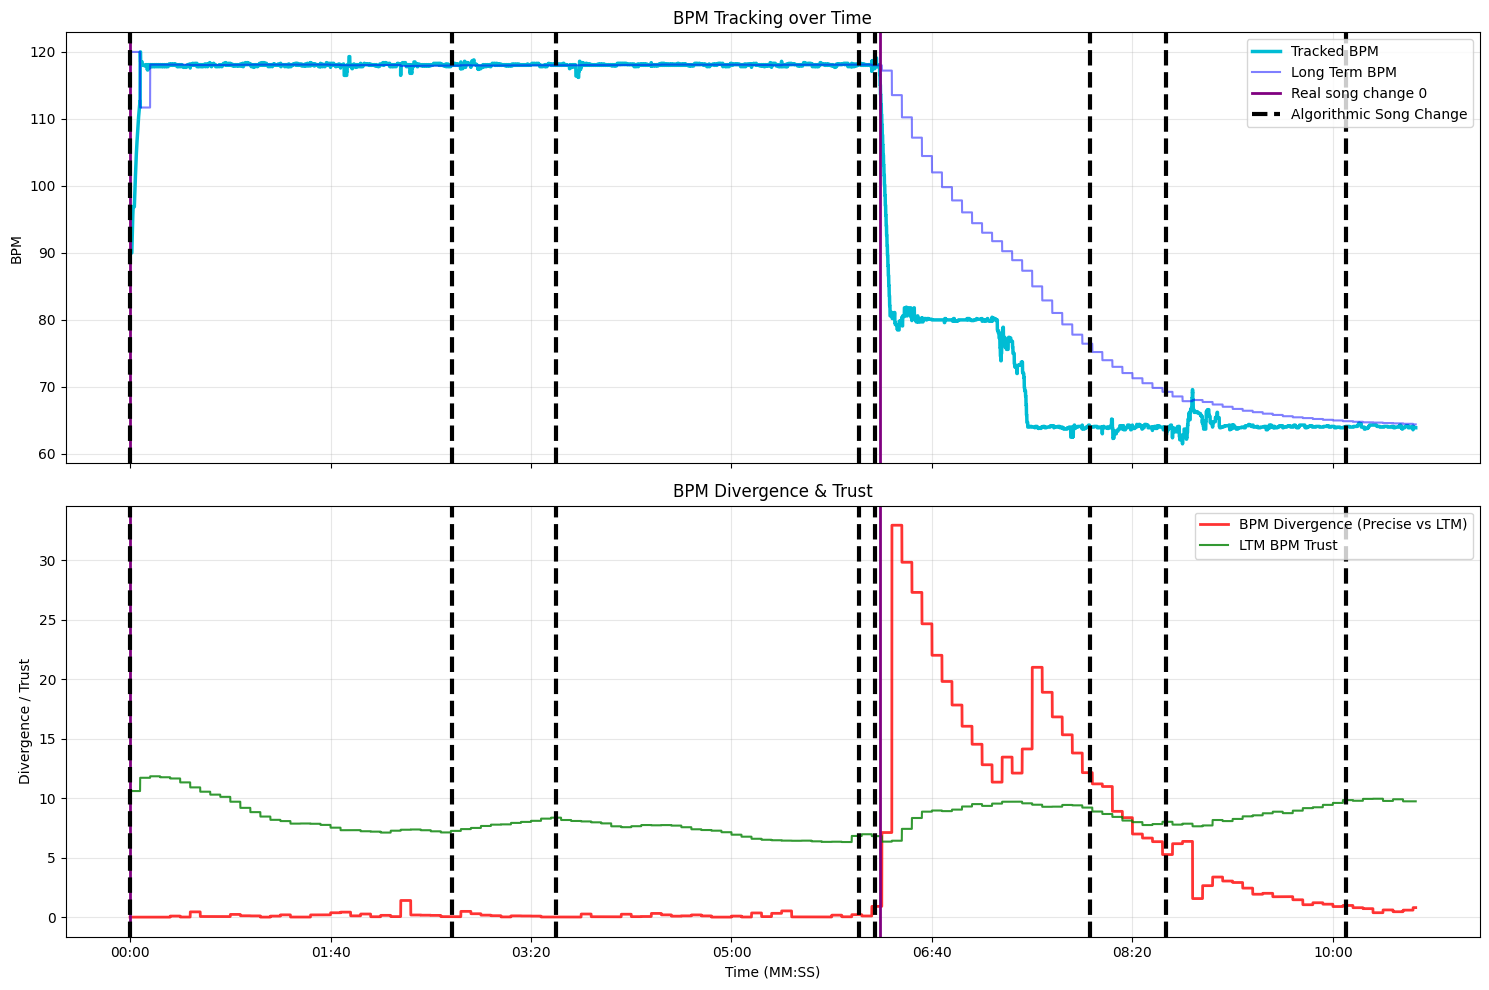

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
def min_sec_formatter(x, pos):
    m = int(x // 60)
    s = int(x % 60)
    return f'{m:02d}:{s:02d}'

time_arr = np.array(history_time)
bpm_arr = np.array(history_bpm)
trust_arr = np.array(history_trust)
diverge_arr = np.array(history_bpm_divergence)
ltm_bpm_arr = np.array(history_ltm_bpm)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

ax1.plot(time_arr, bpm_arr, color='#00bcd4', linewidth=2.5, label='Tracked BPM')
ax1.plot(time_arr, ltm_bpm_arr, color='blue', alpha=0.5, linewidth=1.5, label='Long Term BPM')
ax1.set_title('BPM Tracking over Time')
ax1.set_ylabel('BPM')
ax1.legend(loc='upper right')
ax1.grid(alpha=0.3)

ax2.plot(time_arr, diverge_arr, color='red', alpha=0.8, linewidth=2.0, label='BPM Divergence (Precise vs LTM)')
ax2.plot(time_arr, 20.0*trust_arr, color='green', alpha=0.8, linewidth=1.5, label='LTM BPM Trust')
#ax2.axhline(8.0, color='darkred', linestyle='--', linewidth=2.0, label='BPM Jump Threshold (8.0)')
ax2.set_title('BPM Divergence & Trust')
ax2.set_ylabel('Divergence / Trust')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.3)

y = 0
for k in range(len(y_list)):
    y_k = y_list[k]
    real_change_time = y / sr
    ax1.axvline(real_change_time, color='purple', linestyle='-', linewidth=2, label=f'Real song change {k}' if k==0 else '')
    ax2.axvline(real_change_time, color='purple', linestyle='-', linewidth=2)
    y += len(y_k)

for sid, s_time in enumerate(song_changes):
    ax1.axvline(s_time, color='black', linestyle='--', linewidth=3, label='Algorithmic Song Change' if sid == 0 else '')
    ax2.axvline(s_time, color='black', linestyle='--', linewidth=3)

ax1.legend(loc='upper right')
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(min_sec_formatter))
plt.xlabel('Time (MM:SS)')
plt.tight_layout()
plt.savefig('bpm_performances.png')
plt.show()


### 7. Beat Detection/Prediction Performances

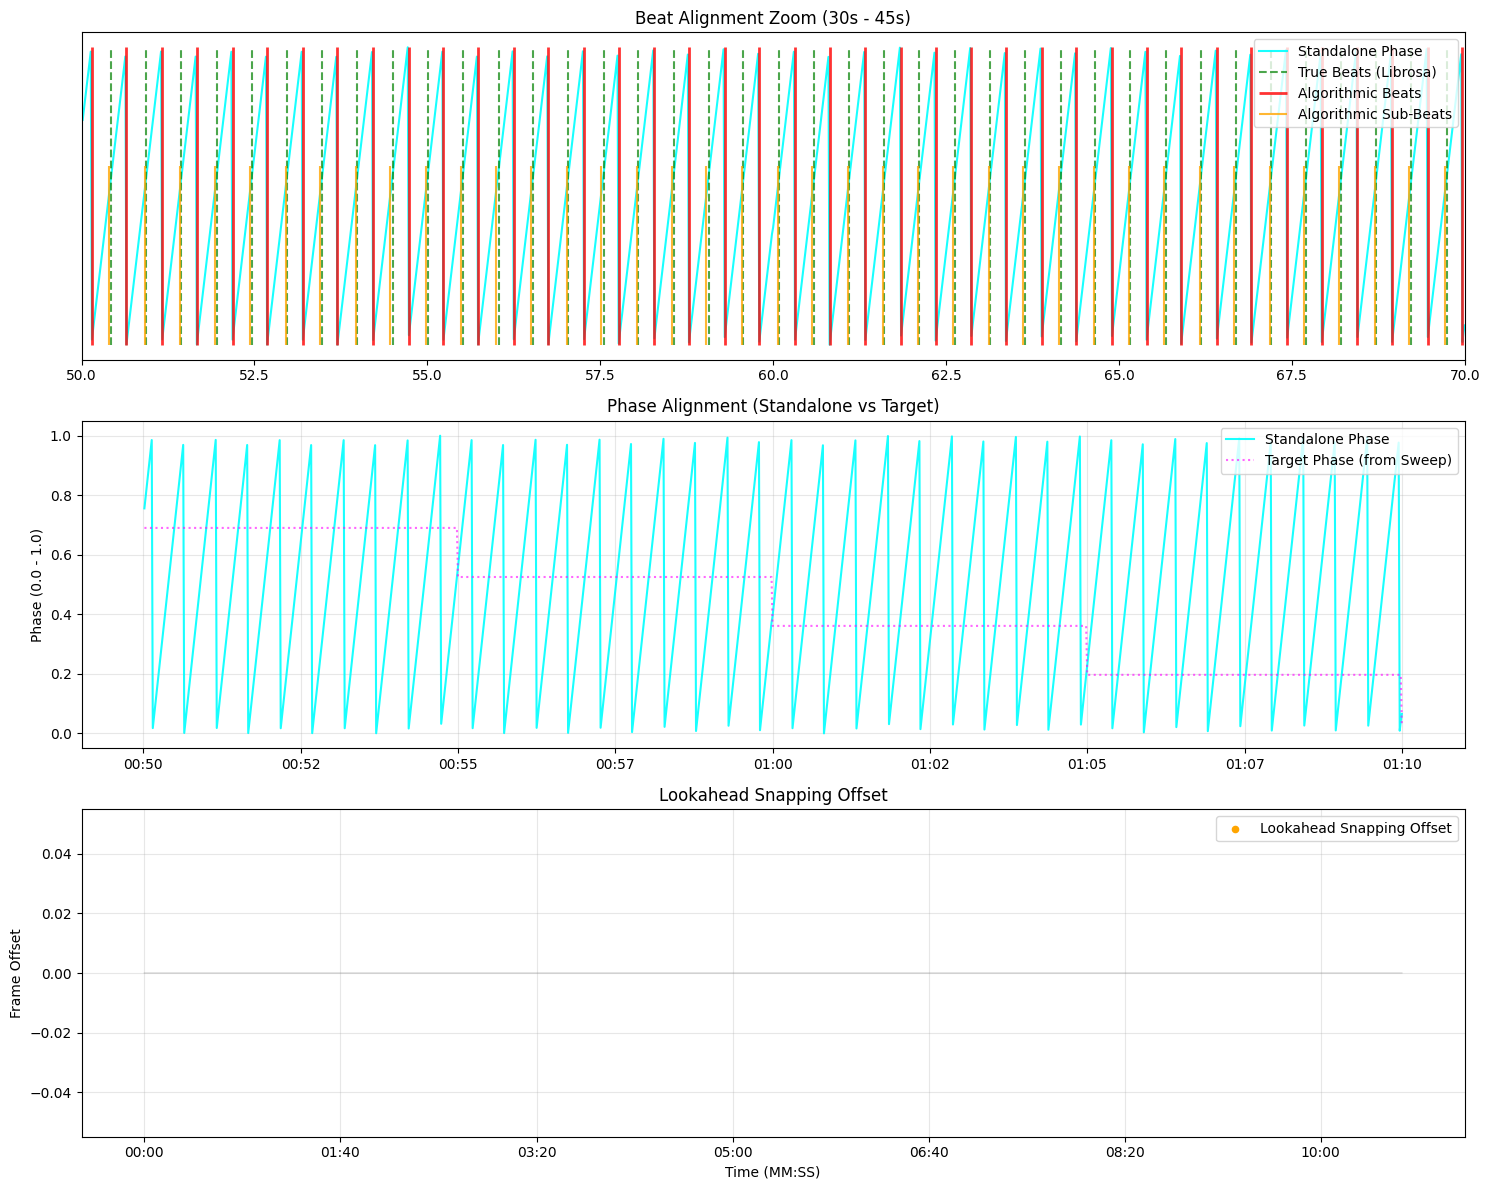

In [7]:
stand_phase_arr = np.array(history_standalone_phase)
targ_phase_arr = np.array(history_target_phase)
snap_arr = np.array(history_snap_offset)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=False)

# Flatten true beats from librosa
all_true_beats = np.concatenate(true_beat_times_list) if len(true_beat_times_list) > 0 else []

# Find a good window to zoom in (e.g. 30 to 45 seconds)
zoom_start = 50.0
zoom_end = 70.0
mask_true = (all_true_beats >= zoom_start) & (all_true_beats <= zoom_end)
mask_alg = (alg_beats_array >= zoom_start) & (alg_beats_array <= zoom_end)
mask_sub = (alg_sub_beats_array >= zoom_start) & (alg_sub_beats_array <= zoom_end)
time_true = (time_arr >= zoom_start) & (time_arr <= zoom_end)
ax1.plot(time_arr[time_true], stand_phase_arr[time_true], color='cyan', alpha=0.9, linewidth=1.5, label='Standalone Phase')
ax1.vlines(all_true_beats[mask_true], ymin=0, ymax=1, color='green', linestyle='--', alpha=0.7, label='True Beats (Librosa)')
ax1.vlines(alg_beats_array[mask_alg], ymin=0, ymax=1, color='red', linestyle='-', alpha=0.8, linewidth=2, label='Algorithmic Beats')
ax1.vlines(alg_sub_beats_array[mask_sub], ymin=0, ymax=0.6, color='orange', linestyle='-', alpha=0.8, linewidth=1.5, label='Algorithmic Sub-Beats')
ax1.set_xlim(zoom_start, zoom_end)
ax1.set_title('Beat Alignment Zoom (30s - 45s)')
ax1.set_yticks([])
ax1.legend(loc='upper right')

time_true = (time_arr >= zoom_start) & (time_arr <= zoom_end)
ax2.plot(time_arr[time_true], stand_phase_arr[time_true], color='cyan', alpha=0.9, linewidth=1.5, label='Standalone Phase')
ax2.plot(time_arr[time_true], targ_phase_arr[time_true], color='magenta', alpha=0.6, linewidth=1.5, linestyle=':', label='Target Phase (from Sweep)')
ax2.set_title('Phase Alignment (Standalone vs Target)')
ax2.set_ylabel('Phase (0.0 - 1.0)')
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(min_sec_formatter))
ax2.legend(loc='upper right')
ax2.grid(alpha=0.3)

mask_snap = snap_arr != 0
ax3.plot(time_arr, snap_arr, color='grey', alpha=0.3, linewidth=1.0)
ax3.scatter(time_arr[mask_snap], snap_arr[mask_snap], color='orange', s=20, label='Lookahead Snapping Offset')
ax3.set_title('Lookahead Snapping Offset')
ax3.set_ylabel('Frame Offset')
ax3.set_xlabel('Time (MM:SS)')
ax3.xaxis.set_major_formatter(ticker.FuncFormatter(min_sec_formatter))
ax3.legend(loc='upper right')
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('beat_performances.png')
plt.show()


### 8. Song Change and Structural Change Performances

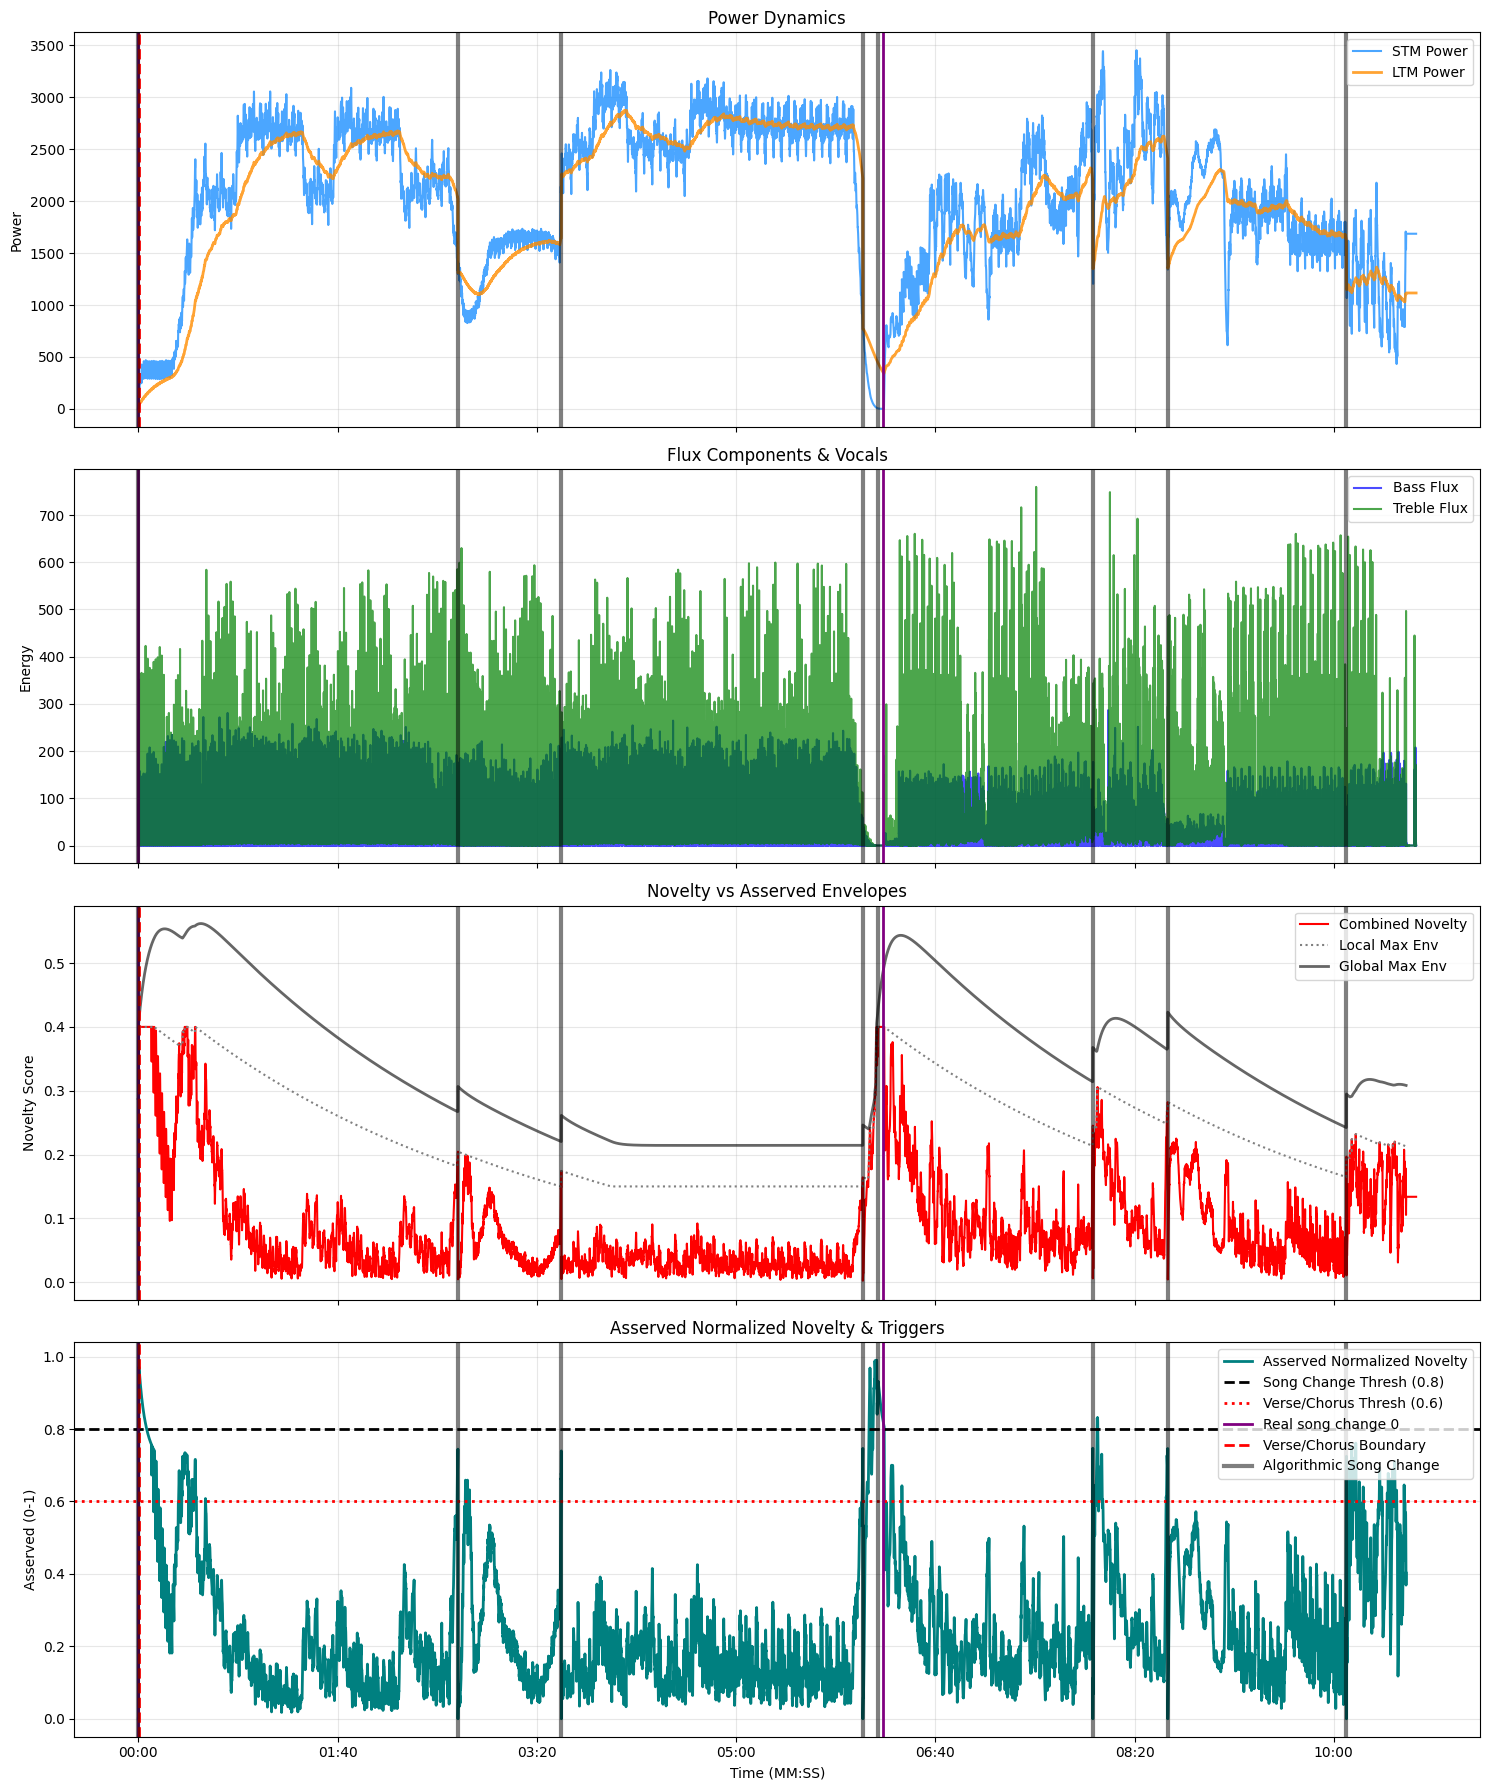

In [8]:
stm_power_arr = np.array(history_stm_power)
ltm_power_arr = np.array(history_ltm_power)
timbral_nov_arr = np.array(history_timbral_nov)
power_nov_arr = np.array(history_power_nov)
combined_nov_arr = np.array(history_combined_nov)
nov_lm_arr = np.array(history_novelty_lm)
nov_gm_arr = np.array(history_novelty_gm)
asserved_nov_arr = np.array(history_asserved_nov)
bass_arr = np.array(history_bass)
treble_arr = np.array(history_treble)

fig, axes = plt.subplots(4, 1, figsize=(15, 18), sharex=True)
ax1, ax2, ax3, ax4 = axes

ax1.plot(time_arr, stm_power_arr, color='dodgerblue', alpha=0.8, linewidth=1.5, label='STM Power')
ax1.plot(time_arr, ltm_power_arr, color='darkorange', alpha=0.8, linewidth=2.0, label='LTM Power')
ax1.set_title('Power Dynamics')
ax1.set_ylabel('Power')
ax1.legend(loc='upper right')
ax1.grid(alpha=0.3)

ax2.plot(time_arr, bass_arr, color='blue', alpha=0.7, linewidth=1.5, label='Bass Flux')
ax2.plot(time_arr, treble_arr, color='green', alpha=0.7, linewidth=1.5, label='Treble Flux')
ax2.set_title('Flux Components & Vocals')
ax2.set_ylabel('Energy')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.3)

ax3.plot(time_arr, combined_nov_arr, color='red', linewidth=1.5, label='Combined Novelty')
ax3.plot(time_arr[:len(nov_lm_arr)], nov_lm_arr, color='grey', linestyle=':', label='Local Max Env')
ax3.plot(time_arr[:len(nov_gm_arr)], nov_gm_arr, color='black', linewidth=2.0, alpha=0.6, label='Global Max Env')
ax3.set_title('Novelty vs Asserved Envelopes')
ax3.set_ylabel('Novelty Score')
ax3.legend(loc='upper right')
ax3.grid(alpha=0.3)

ax4.plot(time_arr[:len(asserved_nov_arr)], asserved_nov_arr, color='teal', linewidth=2.0, label='Asserved Normalized Novelty')
ax4.axhline(0.8, color='black', linestyle='--', linewidth=2.0, label='Song Change Thresh (0.8)')
ax4.axhline(0.6, color='red', linestyle=':', linewidth=2.0, label='Verse/Chorus Thresh (0.6)')
ax4.set_title('Asserved Normalized Novelty & Triggers')
ax4.set_xlabel('Time (MM:SS)')
ax4.set_ylabel('Asserved (0-1)')
ax4.legend(loc='upper right')
ax4.grid(alpha=0.3)

y = 0
for k in range(len(y_list)):
    y_k = y_list[k]
    real_change_time = y / sr
    for ax in axes:
        ax.axvline(real_change_time, color='purple', linestyle='-', linewidth=2, label=f'Real song change {k}' if k==0 else '')
    y += len(y_k)

for sid, s_time in enumerate(structural_changes):
    ax1.axvline(s_time, color='red', linestyle='--', linewidth=2)
    ax3.axvline(s_time, color='red', linestyle='--', linewidth=2)
    ax4.axvline(s_time, color='red', linestyle='--', linewidth=2, label='Verse/Chorus Boundary' if sid == 0 else '')

for sid, s_time in enumerate(song_changes):
    for ax in axes:
        ax.axvline(s_time, color='black', linestyle='-', linewidth=3, alpha=0.5, label='Algorithmic Song Change' if sid == 0 else '')

for ax in axes:
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(min_sec_formatter))

ax4.legend(loc='upper right')
plt.tight_layout()
plt.savefig('structural_performances.png')
plt.show()
